In [1]:
from utility.plot_spectrum import plot_spectrum
from utility.adjust_redshift import adjust_redshift
from utility.my_colors import palette_light, pink

from processing.remove_spikes import remove_spikes
from processing.fit_continuum import fit_continuum
from processing.quality_cuts import quality_cuts
from processing.make_bal_mask import make_bal_mask
from processing.fit_gaussians import fit_single_gaussian, fit_two_gaussians, ftest_which_gaussian
from processing.measure_line import measure_line
from processing.get_absorption_interval import get_absorption_interval
from processing.parameters import CONTINUUM_WINDOWS

from sparcl.client import SparclClient
from dl import queryClient as qc
from astropy.table import Table
from astropy.convolution import convolve, Gaussian1DKernel
from scipy.signal import argrelmin, argrelmax
from scipy.interpolate import interp1d
from datetime import datetime
from ast import literal_eval

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import warnings
import json
import os

relevant_erq_data_path = "data/relevant_erq_data.csv"

pd.options.mode.chained_assignment = None

In [2]:
converters = {"wavelength": literal_eval, "flux":literal_eval, "ivar":literal_eval}

data = pd.read_csv(relevant_erq_data_path,index_col=0,converters=converters)

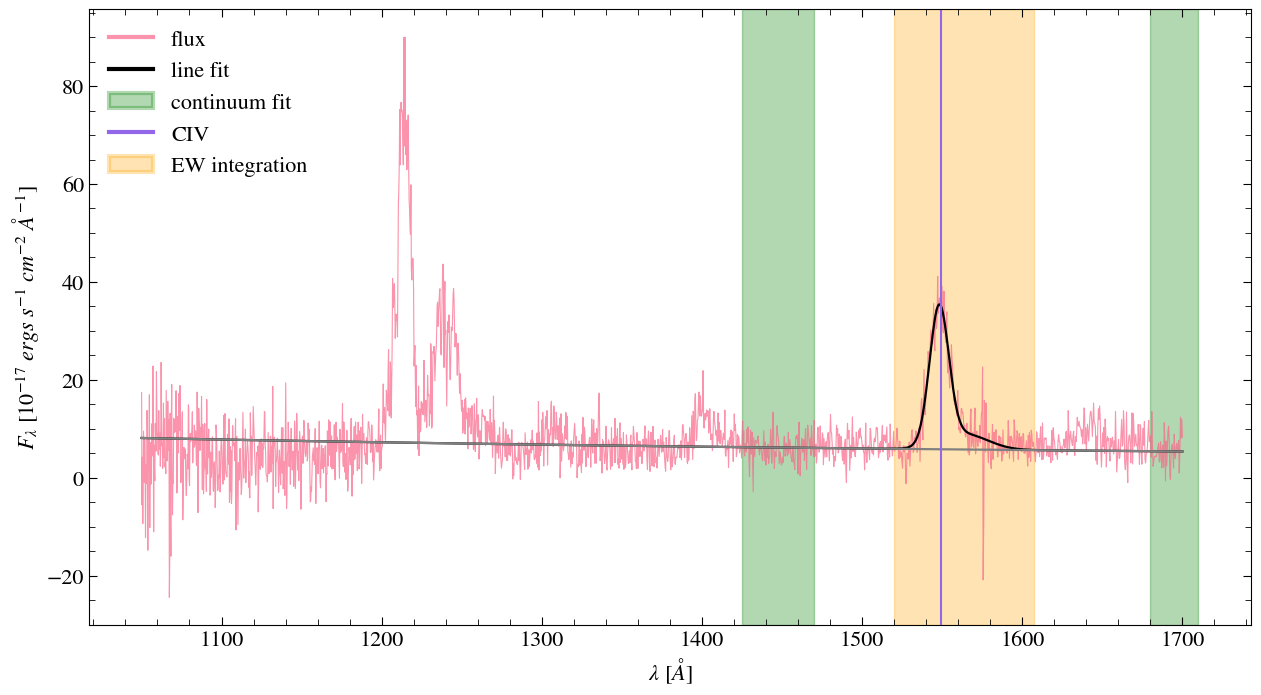


            SDSS: 014111.13-031852.5
            FWHM: 2866.078 vs 2985.648 (Hamann)
            REW: 97.224 vs 101.008 (Hamann) vs 91.83 (fit area)
            kt80: 0.35 vs 0.372 (Hamann)



In [3]:
idx = 6

lam = np.array(data["wavelength"][idx])
flux = np.array(data["flux"][idx])
ivar = np.array(data["ivar"][idx])
z = data["redshift"][idx]

lam, flux, ivar = adjust_redshift(z, lam, flux, ivar=ivar)

# flux = convolve(flux, Gaussian1DKernel(1))

flux_clean, spike_mask = remove_spikes(lam,flux,ivar=ivar,sigma_thresh=3)

result, continuum, window_mask = fit_continuum(lam, flux_clean, ivar=ivar)

rejected, reason, flags = quality_cuts(lam, flux_clean, continuum, result, max_slope=10)

if rejected:
    print(f'SDSS: {data["sdss_name"][idx]}\nRejected because: {reason}')
    plot_spectrum(lam, flux_clean, add_smoothed=False)

flux_sub = flux_clean - continuum if not rejected else None

absorption_interval = get_absorption_interval(lam,flux,ivar)

if absorption_interval is not None:
    bal_mask = (lam > absorption_interval[0]) & (lam < absorption_interval[1])
else:
    bal_mask = None
# bal_mask = make_bal_mask(lam, flux_sub, ivar=ivar, min_width_aa=5)

result1, profile1 = fit_single_gaussian(lam, flux_sub, ivar=ivar, mask=bal_mask)
result2, profile2 = fit_two_gaussians(lam, flux_sub, ivar=ivar, mask=bal_mask, single_result=result1)

accept_two, p_val = ftest_which_gaussian(result1, result2)

if accept_two:
    sigma_w = result2.params["sigma_w"].value
    sigma_c = result2.params["sigma_c"].value
    mu_w = result2.params["cen_w"].value
    mu_c = result2.params["cen_c"].value

    lower = min(mu_c-3*sigma_c,mu_w-3*sigma_w)
    upper = max(mu_c+3*sigma_c,mu_w+3*sigma_w)
    ci = (lower,upper)

    # if sigma_w > sigma_c:
    #     sigma = sigma_w
    #     mu = result2.params["cen_w"].value
    # else:
    #     sigma = sigma_c
    #     mu = result2.params["cen_c"].value
    # ci = (mu-2*sigma, mu+2*sigma)
else:
    mu = result1.params["center"].value
    sigma = result1.params["sigma"].value
    ci = (mu-3*sigma, mu+3*sigma)

# ci = (mu-2*sigma, mu+2*sigma)

plot_mask = (lam >= 1050) & (lam <= 1700)
continuum_mask = plot_mask#(lam >= 1425) & (lam <= 1810)

if absorption_interval is not None:
    if accept_two:
        line_stats, win = measure_line(lam, profile2, flux_sub, continuum, ci, get_window=True)
        plot_spectrum(lam[plot_mask], flux[plot_mask], flux_label="flux",
            line_width_factor=2,
            add_smoothed=False,
            additional_lam=[lam[continuum_mask]]*2,
            additional_flux=[profile2[continuum_mask]+continuum[continuum_mask],continuum[continuum_mask]],
            additional_flux_label=["line fit","continuum fit"],
            line_lambda=[1549],
            line_label=["CIV"],
            shaded_regions=CONTINUUM_WINDOWS[:2]+[(lam[win][0], lam[win][-1]), absorption_interval],
            shaded_regions_colors=["green"]*2+["orange","DodgerBlue"],
            shaded_regions_label=["continuum fit"]*2+["integration","absorption mask"]
            )
    else:
        line_stats, win = measure_line(lam, profile1, flux_sub, continuum, ci, get_window=True)
        plot_spectrum(lam[plot_mask], flux[plot_mask], flux_label="flux",
            line_width_factor=2,
            add_smoothed=False,
            additional_lam=[lam[continuum_mask]]*2,
            additional_flux=[profile1[continuum_mask]+continuum[continuum_mask], continuum[continuum_mask]],
            additional_flux_label=["line fit","continuum fit"],
            line_lambda=[1549],
            line_label=["CIV"],
            shaded_regions=CONTINUUM_WINDOWS[:2]+[(lam[win][0], lam[win][-1]), absorption_interval],
            shaded_regions_colors=["green"]*2+["orange","DodgerBlue"],
            shaded_regions_label=["continuum fit"]*2+["integration","absorption mask"]
            )
else:
    if accept_two:
        line_stats, win = measure_line(lam, profile2, flux_sub, continuum, ci, get_window=True)
        plot_spectrum(lam[plot_mask], flux[plot_mask], flux_label="flux",
            line_width_factor=2,
            add_smoothed=False,
            additional_lam=[lam[continuum_mask]]*2,
            additional_flux=[profile2[continuum_mask]+continuum[continuum_mask],continuum[continuum_mask]],
            additional_flux_label=["line fit","continuum fit"],
            line_lambda=[1549],
            line_label=["CIV"],
            shaded_regions=CONTINUUM_WINDOWS[:2]+[(lam[win][0], lam[win][-1])],
            shaded_regions_colors=["green"]*2+["orange"],
            shaded_regions_label=["continuum fit"]*2+["EW integration"]
            )
    else:
        line_stats, win = measure_line(lam, profile1, flux_sub, continuum, ci, get_window=True)
        plot_spectrum(lam[plot_mask], flux[plot_mask], flux_label="flux",
            line_width_factor=2,
            add_smoothed=False,
            additional_lam=[lam[continuum_mask]]*2,
            additional_flux=[profile1[continuum_mask]+continuum[continuum_mask], continuum[continuum_mask]],
            additional_flux_label=["line fit","continuum fit"],
            line_lambda=[1549],
            line_label=["CIV"],
            shaded_regions=CONTINUUM_WINDOWS[:2]+[(lam[win][0], lam[win][-1])],
            shaded_regions_colors=["green"]*2+["orange"],
            shaded_regions_label=["continuum fit"]*2+["EW integration"]
            )

out_str = f'''
            SDSS: {data["sdss_name"][idx]}
            FWHM: {round(line_stats["fwhm_kms"],3)} vs {round(data["fwhm"][idx],3)} (Hamann)
            REW: {round(line_stats["ew_aa"],3)} vs {round(data["rew"][idx],3)} (Hamann) vs {round(line_stats["fit_rew"],3)} (fit area)
            kt80: {round(line_stats["kt80"],3)} vs {round(data["kt80"][idx],3)} (Hamann)
'''

print(out_str)

In [4]:
from utility.get_intercepts_near_line import get_intercepts_near_line

LYA = 1215
NV = 1242

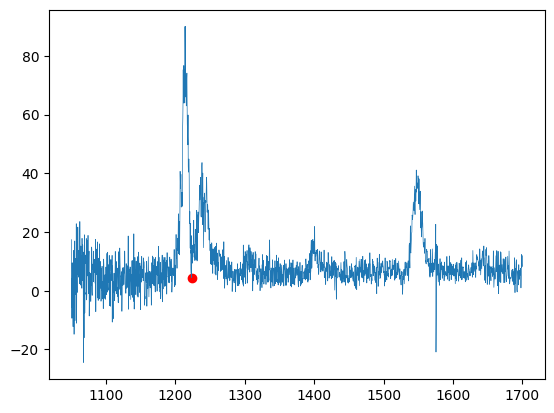

In [17]:
interval_mask = (lam <= NV) & (lam >= LYA)
interval_min = np.argmin(flux[interval_mask])

plt.plot(lam[plot_mask],flux[plot_mask], linewidth=0.5)
plt.scatter(lam[interval_mask][interval_min],flux[interval_mask][interval_min],color="red")

In [16]:
interval_min

29

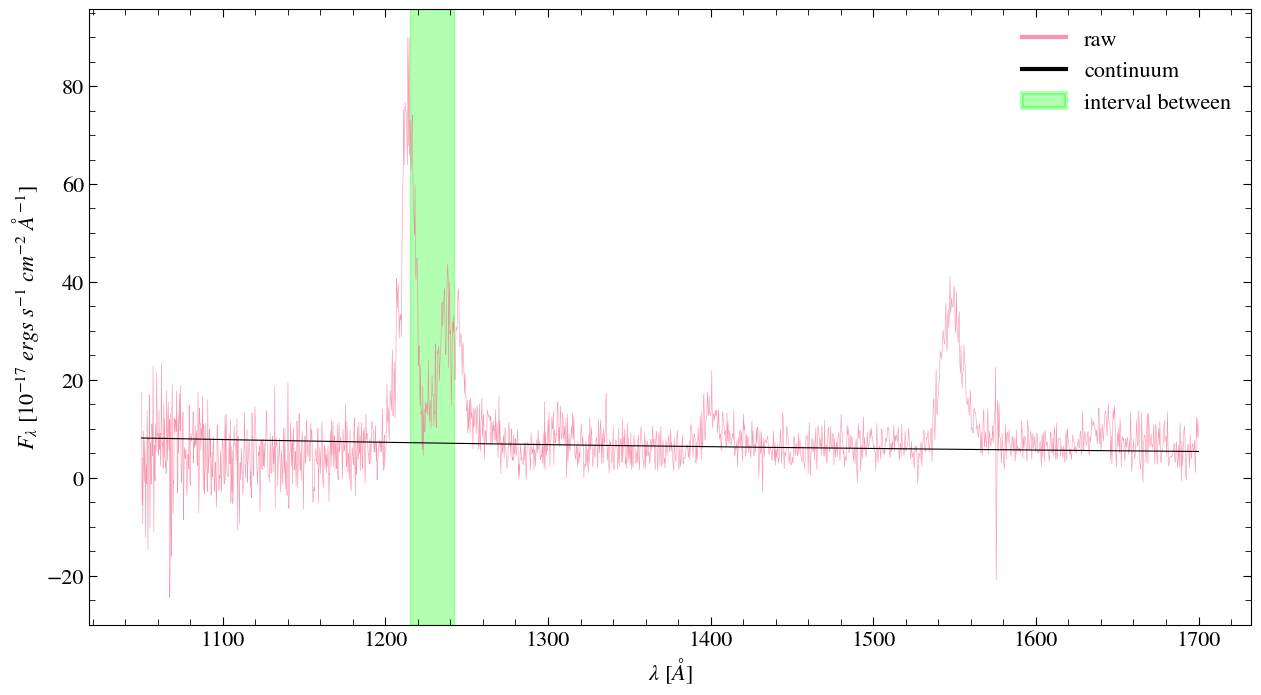

In [7]:
plot_spectrum(lam[plot_mask],flux[plot_mask],add_smoothed=False,additional_flux=[continuum[plot_mask]], additional_flux_label=["continuum"],shaded_regions=[(LYA,NV)],shaded_regions_label=["interval between"])